<a href="https://colab.research.google.com/github/gbaranaos/iele756-region-4/blob/main/Tarea2_comuna_13101_Santiago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Tarea 2: Health Landscape – ENO + GRD
**Curso:** IELE756 – Preparación y Análisis de Datos  
**Alumno:** Guillermo Barañao

**Fecha:** 16 de Abril 2026  
**Comuna asignada:** Santiago (`13101`)  

En este notebook se construye un perfil de salud para la comuna de Santiago usando dos fuentes:
- **ENO** (Enfermedades de Notificación Obligatoria), 2007–2024.
- **GRD** (egresos hospitalarios), 2022–2024.



## 1. Configuración inicial
Primero cargamos librerías, definimos rutas y reconstruimos la población comunal.

Se calcula la población total, población chilena y extranjera, y el porcentaje de población extranjera.




In [ ]:
import os
import zipfile
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

try:
    import geopandas as gpd
except ImportError:
    gpd = None

BASE = "/content"

FILES = {
    "tarea1": os.path.join(BASE, "tarea1_comuna_summary.csv"),
    "personas": os.path.join(BASE, "personas_censo2024.parquet"),
    "eno": os.path.join(BASE, "20241218_base_eno_final (1).csv"),
    "grd_2022": os.path.join(BASE, "GRD_PUBLICO_2022.zip"),
    "grd_2023": os.path.join(BASE, "GRD_PUBLICO_2023.zip"),
    "grd_2024": os.path.join(BASE, "GRD_PUBLICO_2024 (1).zip"),
    "cie10": os.path.join(BASE, "CIE-10 (1).xlsx"),
    "severidad": os.path.join(BASE, "TablasMaestrasBasesGRD.xlsx"),
    "shp_original": os.path.join(BASE, "comunas (1).shp"),
    "shp_fixed": os.path.join(BASE, "comunas.shp"),
}

MY_COMUNAS = [13101]
MY_COMUNA_NAMES = ["SANTIAGO"]

os.makedirs(os.path.join(BASE, "output"), exist_ok=True)


In [ ]:
# Cargar la tabla antigua de Tarea 1 solo para comparar
tarea1_original = pd.read_csv(FILES["tarea1"])
print("Shape tarea1 original:", tarea1_original.shape)
print("Columnas:", tarea1_original.columns.tolist())
display(tarea1_original)

# Reconstruir población correcta desde personas_censo2024.parquet
personas = pd.read_parquet(
    FILES["personas"],
    columns=["comuna", "p27_nacionalidad_rec"]
)

personas["comuna"] = pd.to_numeric(personas["comuna"], errors="coerce").astype("Int64")
personas_com = personas[personas["comuna"].isin(MY_COMUNAS)].copy()

personas_com["born_group"] = personas_com["p27_nacionalidad_rec"].astype(str).replace({
    "Chileno(a)": "Chilean",
    "Extranjero(a)": "Foreign",
    "Chileno(a) y extranjero(a)": "Chilean"
})

# Manejo alternativo por si la categoría viene con otro texto
personas_com["born_group"] = np.where(
    personas_com["born_group"].astype(str).str.contains("Extranj", case=False, na=False),
    "Foreign",
    "Chilean"
)

tarea1 = (
    personas_com.groupby("comuna")
    .agg(
        pop_total=("comuna", "size"),
        pop_chilean=("born_group", lambda x: (x == "Chilean").sum()),
        pop_foreign=("born_group", lambda x: (x == "Foreign").sum())
    )
    .reset_index()
    .rename(columns={"comuna": "codigo_comuna"})
)

name_map = {13101: "Santiago"}
tarea1["nombre_comuna"] = tarea1["codigo_comuna"].map(name_map).fillna(tarea1["codigo_comuna"].astype(str))
tarea1["pct_foreign"] = tarea1["pop_foreign"] / tarea1["pop_total"] * 100

print("Tabla de población reconstruida desde personas_censo2024.parquet:")
display(tarea1)

print("Comparación rápida con la tabla original:")
compare_cols = [c for c in ["codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign", "pct_foreign"] if c in tarea1_original.columns]
display(tarea1_original[compare_cols] if compare_cols else tarea1_original)


Shape tarea1 original: (1, 13)
Columnas: ['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio']


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13101,Santiago,5806,258429,176956,3047.812608,35.0,34.0,14.421518,13.805328,0.726586,0.833405,0.262107


Tabla de población reconstruida desde personas_censo2024.parquet:


,codigo_comuna,pop_total,pop_chilean,pop_foreign,nombre_comuna,pct_foreign
0,13101,438856,438856,0,Santiago,0.0


Comparación rápida con la tabla original:


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign
0,13101,Santiago,5806,258429,176956,3047.812608


## 2. Revisión y corrección de la base poblacional
Desde este punto se usa la tabla reconstruida desde `personas_censo2024.parquet` como fuente oficial para `pop_total`, `pop_chilean`, `pop_foreign` y `pct_foreign`.




In [ ]:
# Asegurar tipos
tarea1["codigo_comuna"] = pd.to_numeric(tarea1["codigo_comuna"], errors="coerce").astype("Int64")
tarea1["nombre_comuna"] = tarea1["nombre_comuna"].astype(str)

# Filtrar a mis comunas
tarea1_com = tarea1[tarea1["codigo_comuna"].isin(MY_COMUNAS)].copy()
display(tarea1_com)


,codigo_comuna,pop_total,pop_chilean,pop_foreign,nombre_comuna,pct_foreign
0,13101,438856,438856,0,Santiago,0.0



## Parte A: ENO – Enfermedades de Notificación Obligatoria

- cargar ENO con separador `;`
- filtrar a las comunas asignadas
- reportar el problema de comunas anonimizadas (`"*****"`)
- limpiar `nacionalidad`
- construir tendencias, perfiles por enfermedad y una tabla resumen comunal.



### A.0 Carga y limpieza de ENO


In [ ]:

eno_cols = [
    "ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
    "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
    "cie_10_diagnostico", "diagnostico", "pais_contagio"
]

eno = pd.read_csv(
    FILES["eno"],
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols,
    low_memory=False
)

print("Shape ENO:", eno.shape)
eno.info()
display(eno.head())


Shape ENO: (333300, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


,region,nacionalidad,cie_10_diagnostico,diagnostico,anho_notificacion,ENO,nombre_instruccion,pais_contagio,sexo,grupo_edad,codigo_comuna_residencia
0,Región de Tarapacá,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,25-29,01107
1,Región de Valparaíso,Desconocido,A90.X,FIEBRE DEL DENGUE,2018,Arbovirus,Desconocido,Desconocido,hombre,70-74,05301
2,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,70-74,05109
3,Región de Valparaíso,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2019,Arbovirus,Desconocido,Desconocido,hombre,40-44,05301
4,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2021,Arbovirus,Desconocido,Desconocido,hombre,60-64,05109


In [ ]:

# Conteo de comunas anonimizadas
anon_count = (eno["codigo_comuna_residencia"].astype(str) == "*****").sum()
anon_pct = anon_count / len(eno) * 100
print(f"Filas anonimizadas en ENO: {anon_count:,} ({anon_pct:.2f}%)")

# Filtrar a mis comunas
eno["codigo_comuna_residencia"] = eno["codigo_comuna_residencia"].astype(str)
my_comunas_str = [str(c) for c in MY_COMUNAS]
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()

print(f"Filas ENO en mis comunas: {len(eno_com):,}")
display(eno_com.head())


Filas anonimizadas en ENO: 148,217 (44.47%)
Filas ENO en mis comunas: 12,186


,region,nacionalidad,cie_10_diagnostico,diagnostico,anho_notificacion,ENO,nombre_instruccion,pais_contagio,sexo,grupo_edad,codigo_comuna_residencia
24,Región Metropolitana de Santiago,Chile,A97.9,"DENGUE, NO ESPECIFICADO",2019,Arbovirus,Desconocido,Desconocido,hombre,30-34,13101
29,Región Metropolitana de Santiago,Desconocido,A90.X,FIEBRE DEL DENGUE,2018,Arbovirus,Desconocido,Desconocido,mujer,25-29,13101
48,Región Metropolitana de Santiago,Extranjero,A97.1,DENGUE CON DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,35-39,13101
146,Región Metropolitana de Santiago,Extranjero,A97.1,DENGUE CON DATOS DE ALARMA,2022,Arbovirus,Desconocido,Desconocido,mujer,55-59,13101
154,Región Metropolitana de Santiago,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2022,Arbovirus,Desconocido,Desconocido,hombre,05-09,13101


In [ ]:

# Distribución de nacionalidad
nat_dist = eno_com["nacionalidad"].value_counts(dropna=False)
nat_dist_pct = eno_com["nacionalidad"].value_counts(dropna=False, normalize=True).mul(100).round(2)
nat_table = pd.DataFrame({"count": nat_dist, "pct": nat_dist_pct})
display(nat_table)

# Excluir Desconocido solo para análisis por nacionalidad
eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()
dropped_nat = len(eno_com) - len(eno_com_nat)
dropped_nat_pct = dropped_nat / len(eno_com) * 100 if len(eno_com) else 0

print(f"Filas excluidas por nacionalidad 'Desconocido': {dropped_nat:,} ({dropped_nat_pct:.2f}%)")


,count,pct
nacionalidad,,
Chile,5059,41.51
Extranjero,3635,29.83
Desconocido,3492,28.66


Filas excluidas por nacionalidad 'Desconocido': 3,492 (28.66%)


In [ ]:

# Rango temporal y notificaciones por año
eno_com["anho_notificacion"] = pd.to_numeric(eno_com["anho_notificacion"], errors="coerce")
year_min = int(eno_com["anho_notificacion"].min())
year_max = int(eno_com["anho_notificacion"].max())
print(f"Rango temporal ENO en mis comunas: {year_min}–{year_max}")

eno_by_year = (
    eno_com.groupby("anho_notificacion")
    .size()
    .reset_index(name="notifications")
    .sort_values("anho_notificacion")
)
display(eno_by_year)


Rango temporal ENO en mis comunas: 2007–2024


,anho_notificacion,notifications
0,2007,121
1,2008,157
2,2009,303
3,2010,186
4,2011,424
5,2012,307
6,2013,349
7,2014,405
8,2015,415
9,2016,424


### Conclusión

La evolución de las notificaciones ENO en Santiago muestra una tendencia creciente a partir de 2017, con un peak importante en 2018 (1.881 casos) y otro en 2023 (1.746 casos).

Se observa además una caída significativa en los años 2020 y 2021, lo que podría estar asociado a efectos de la pandemia en la detección, notificación o acceso al sistema de salud.

En términos generales, la serie evidencia un aumento en la carga de enfermedades notificables en los últimos años, con cierta recuperación posterior a la pandemia.


### A.1 Tendencias de notificación
Tendencia total por año y tendencia separada por nacionalidad (Chile vs Extranjero, excluyendo Desconocido)


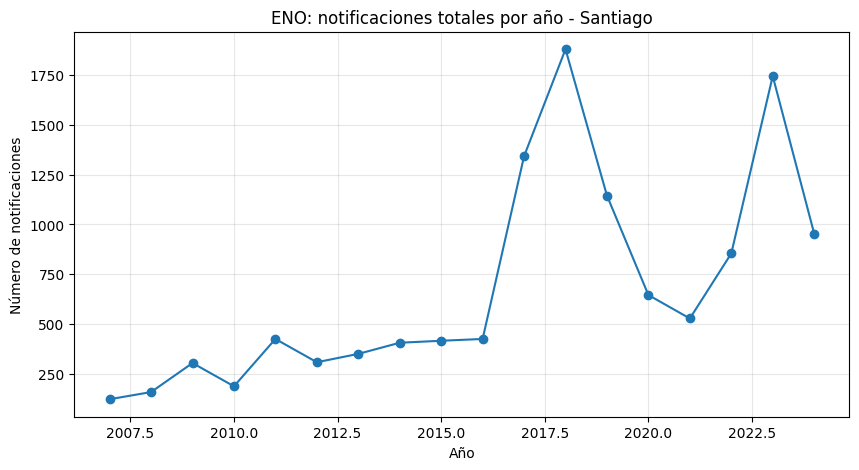

In [ ]:

# Tendencia total
plt.figure(figsize=(10,5))
plt.plot(eno_by_year["anho_notificacion"], eno_by_year["notifications"], marker="o")
plt.title("ENO: notificaciones totales por año - Santiago")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones")
plt.grid(True, alpha=0.3)
plt.show()


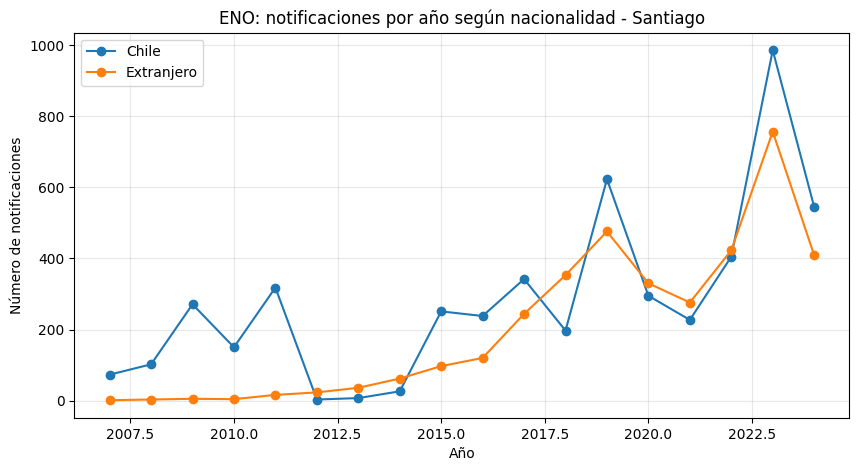

,anho_notificacion,nacionalidad,notifications
0,2007,Chile,73
1,2007,Extranjero,1
2,2008,Chile,102
3,2008,Extranjero,3
4,2009,Chile,271
5,2009,Extranjero,5
6,2010,Chile,150
7,2010,Extranjero,4
8,2011,Chile,318
9,2011,Extranjero,16


In [ ]:

# Tendencia por nacionalidad
eno_by_year_nat = (
    eno_com_nat.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="notifications")
)

pivot_nat = eno_by_year_nat.pivot(index="anho_notificacion", columns="nacionalidad", values="notifications").fillna(0)

plt.figure(figsize=(10,5))
for col in pivot_nat.columns:
    plt.plot(pivot_nat.index, pivot_nat[col], marker="o", label=col)
plt.title("ENO: notificaciones por año según nacionalidad - Santiago")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(eno_by_year_nat.sort_values(["anho_notificacion", "nacionalidad"]))



### Conclusión

Al desagregar por nacionalidad, se observa que la participación de personas extranjeras en las notificaciones aumenta de manera sostenida en el tiempo.

En los primeros años, las notificaciones extranjeras eran marginales, mientras que en años recientes (por ejemplo 2022–2024) alcanzan niveles cercanos a las de población chilena.

Este resultado sugiere un cambio en la composición de la población afectada o en el acceso al sistema de salud, aunque debe interpretarse con cautela debido a la alta proporción de registros con nacionalidad desconocida.


### A.2 Perfil de enfermedades

- top 10 enfermedades notificadas
- perfil por nacionalidad para las top 5
- distribución por grupo etario para la enfermedad más frecuente.


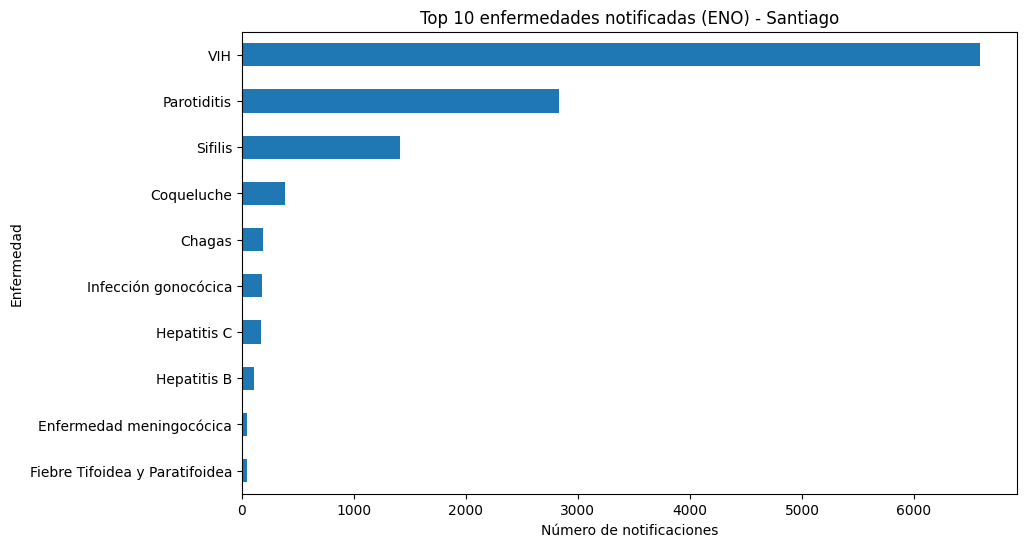

,count,count
0,VIH,6588
1,Parotiditis,2828
2,Sifilis,1408
3,Coqueluche,387
4,Chagas,185
5,Infección gonocócica,178
6,Hepatitis C,171
7,Hepatitis B,111
8,Enfermedad meningocócica,51
9,Fiebre Tifoidea y Paratifoidea,47


In [ ]:

# Top 10 enfermedades
top10_eno = eno_com["ENO"].value_counts().head(10).sort_values()
plt.figure(figsize=(10,6))
top10_eno.plot(kind="barh")
plt.title("Top 10 enfermedades notificadas (ENO) - Santiago")
plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.show()

display(top10_eno.sort_values(ascending=False).reset_index().rename(columns={"index":"ENO","ENO":"count"}))


### Conclusión

El perfil de enfermedades notificadas en Santiago está fuertemente concentrado en VIH, con 6.588 casos, seguido por parotiditis (2.828) y sífilis (1.408).

Esto indica que la carga de enfermedad notificable en la comuna está dominada por infecciones específicas, particularmente enfermedades de transmisión sexual y algunas infecciones prevenibles.

La alta concentración en pocas enfermedades sugiere oportunidades claras de focalización en políticas de salud pública.

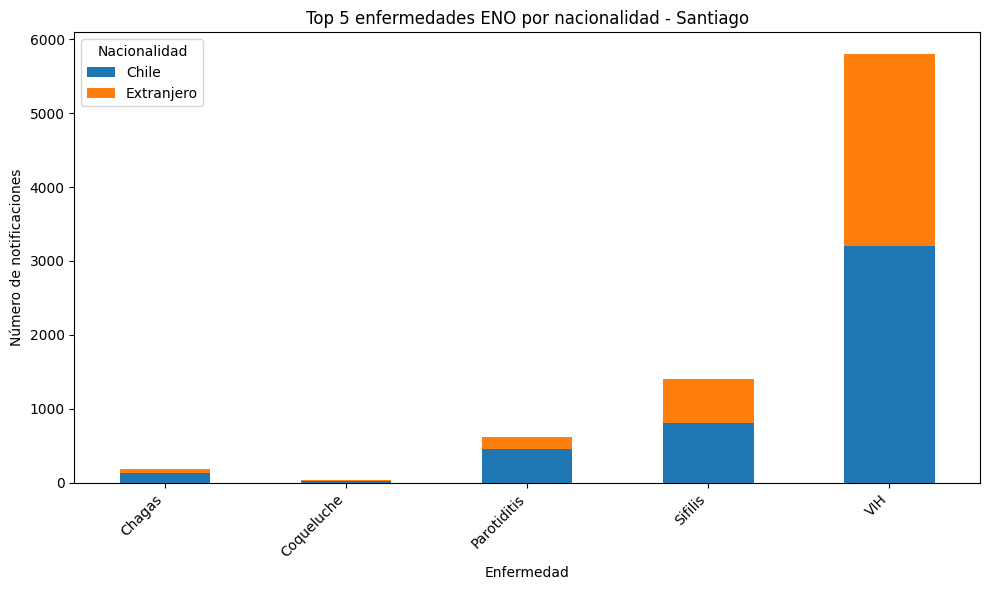

,ENO,nacionalidad,count,share_within_disease
0,Chagas,Chile,129,0.701087
1,Chagas,Extranjero,55,0.298913
2,Coqueluche,Chile,24,0.705882
3,Coqueluche,Extranjero,10,0.294118
4,Parotiditis,Chile,454,0.737013
5,Parotiditis,Extranjero,162,0.262987
6,Sifilis,Chile,805,0.572546
7,Sifilis,Extranjero,601,0.427454
8,VIH,Chile,3198,0.551284
9,VIH,Extranjero,2603,0.448716


In [ ]:

# Top 5 enfermedades por nacionalidad
top5_diseases = eno_com["ENO"].value_counts().head(5).index.tolist()

profile_nat = (
    eno_com_nat[eno_com_nat["ENO"].isin(top5_diseases)]
    .groupby(["ENO", "nacionalidad"])
    .size()
    .reset_index(name="count")
)

profile_nat["share_within_disease"] = profile_nat.groupby("ENO")["count"].transform(lambda s: s / s.sum())

profile_pivot = profile_nat.pivot(index="ENO", columns="nacionalidad", values="count").fillna(0)
profile_pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Top 5 enfermedades ENO por nacionalidad - Santiago")
plt.xlabel("Enfermedad")
plt.ylabel("Número de notificaciones")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

display(profile_nat.sort_values(["ENO", "nacionalidad"]))


### Conclusión

Al analizar las principales enfermedades por nacionalidad, se observa que VIH y sífilis presentan una participación extranjera significativa, cercana al 45% en el caso de VIH.

En contraste, enfermedades como parotiditis, coqueluche y Chagas muestran una mayor proporción de casos en población chilena.

Esto evidencia que la distribución epidemiológica no es homogénea entre nacionalidades, y que ciertas enfermedades tienen una composición más equilibrada entre ambos grupos.

Enfermedad más frecuente: VIH


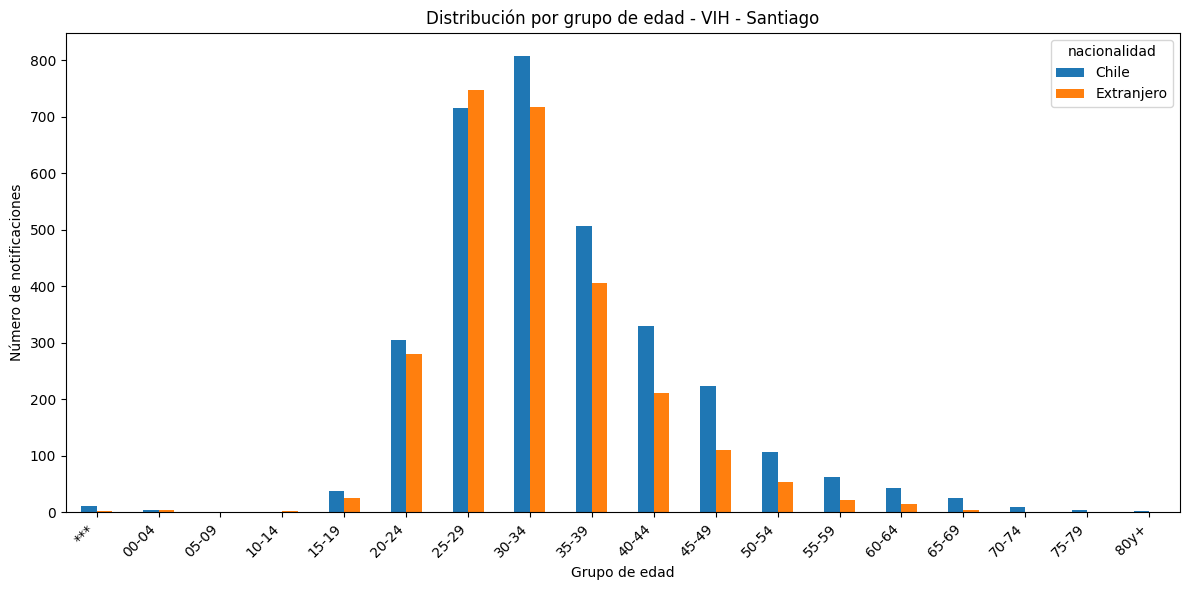

,grupo_edad,nacionalidad,count
0,***,Chile,11
1,***,Extranjero,3
2,00-04,Chile,4
3,00-04,Extranjero,4
4,05-09,Chile,1
5,05-09,Extranjero,1
6,10-14,Chile,1
7,10-14,Extranjero,2
8,15-19,Chile,37
9,15-19,Extranjero,25


In [ ]:

# Distribución por edad de la enfermedad más común
top_disease = eno_com["ENO"].value_counts().idxmax()
print("Enfermedad más frecuente:", top_disease)

age_top = (
    eno_com_nat[eno_com_nat["ENO"] == top_disease]
    .groupby(["grupo_edad", "nacionalidad"])
    .size()
    .reset_index(name="count")
)

age_pivot = age_top.pivot(index="grupo_edad", columns="nacionalidad", values="count").fillna(0)
age_pivot.plot(kind="bar", figsize=(12,6))
plt.title(f"Distribución por grupo de edad - {top_disease} - Santiago")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de notificaciones")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(age_top.sort_values(["grupo_edad", "nacionalidad"]))


### Conclusión

La distribución por grupo etario para VIH muestra una clara concentración en población adulta joven, especialmente entre los 25 y 34 años.

En población chilena el peak se observa en el grupo 30–34 años, mientras que en población extranjera destaca el grupo 25–29 años.

A partir de los 40 años, la frecuencia disminuye progresivamente en ambos grupos, lo que sugiere que la carga de enfermedad se concentra en etapas activas de la vida.


### A.3 Vista espacial: notificaciones por comuna
Conteos por comuna y tasa  por 10.000 habitantes.


,codigo_comuna_residencia,eno_total,codigo_comuna,nombre_comuna,pop_total,eno_rate_per_10k
0,13101,12186,13101,Santiago,438856,277.676504


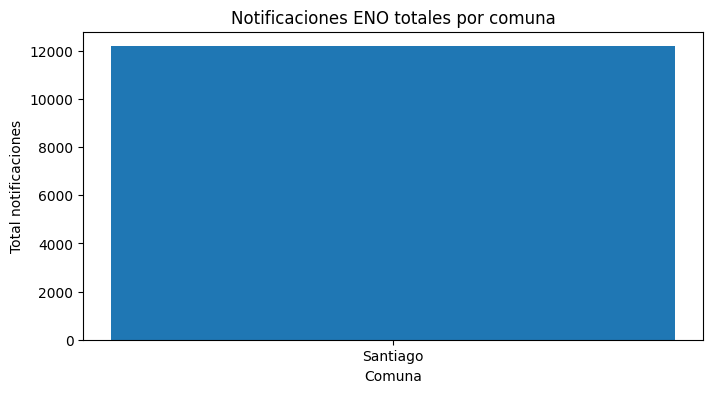

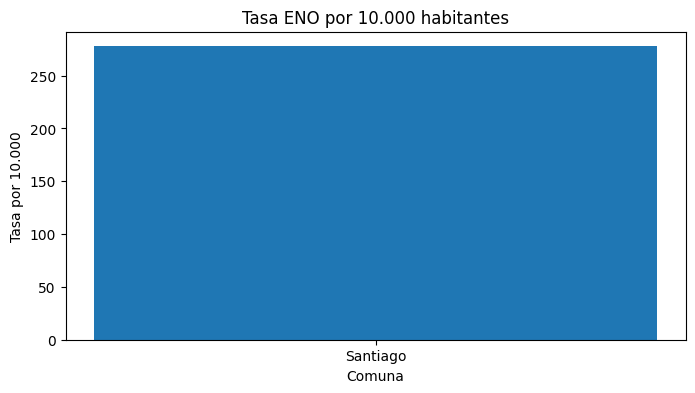

In [ ]:
eno_counts_comuna = (
    eno_com.groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="eno_total")
)

eno_counts_comuna["codigo_comuna"] = pd.to_numeric(
    eno_counts_comuna["codigo_comuna_residencia"], errors="coerce"
).astype("Int64")

eno_rates = eno_counts_comuna.merge(
    tarea1_com[["codigo_comuna", "nombre_comuna", "pop_total"]],
    on="codigo_comuna",
    how="left"
)

eno_rates["eno_rate_per_10k"] = eno_rates["eno_total"] / eno_rates["pop_total"] * 10000
display(eno_rates)

plt.figure(figsize=(8, 4))
plt.bar(eno_rates["nombre_comuna"], eno_rates["eno_total"])
plt.title("Notificaciones ENO totales por comuna")
plt.ylabel("Total notificaciones")
plt.xlabel("Comuna")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(eno_rates["nombre_comuna"], eno_rates["eno_rate_per_10k"])
plt.title("Tasa ENO por 10.000 habitantes")
plt.ylabel("Tasa por 10.000")
plt.xlabel("Comuna")
plt.show()


### Conclusión

La comuna de Santiago registra 12.186 notificaciones ENO, lo que corresponde a una tasa de 277,68 casos por cada 10.000 habitantes.

Esta tasa refleja una carga relevante de enfermedades notificables en la comuna, aunque debe interpretarse considerando que los datos ENO presentan subregistro debido a la anonimización de comunas en una fracción importante de los registros.


### A.4 Tabla resumen comunal ENO
La tabla debe incluir `codigo_comuna`, `nombre_comuna`, conteos por nacionalidad, top 3 enfermedades y tasa por 10.000 habitantes.


In [ ]:
def build_eno_summary(group):
    code = pd.to_numeric(group.name, errors="coerce")
    nombre = tarea1_com.loc[tarea1_com["codigo_comuna"] == code, "nombre_comuna"]
    pop = tarea1_com.loc[tarea1_com["codigo_comuna"] == code, "pop_total"]

    eno_total = len(group)
    eno_chilean = (group["nacionalidad"] == "Chile").sum()
    eno_foreign = (group["nacionalidad"] == "Extranjero").sum()
    eno_desconocido = (group["nacionalidad"] == "Desconocido").sum()
    top3 = ", ".join(group["ENO"].value_counts().head(3).index.tolist())
    pop_total = pop.iloc[0] if len(pop) else np.nan
    rate = eno_total / pop_total * 10000 if pd.notna(pop_total) and pop_total != 0 else np.nan

    return pd.Series({
        "codigo_comuna": code,
        "nombre_comuna": nombre.iloc[0] if len(nombre) else np.nan,
        "pop_total": pop_total,
        "eno_total": eno_total,
        "eno_chilean": eno_chilean,
        "eno_foreign": eno_foreign,
        "eno_desconocido": eno_desconocido,
        "eno_top3_diseases": top3,
        "eno_rate_per_10k": rate
    })

eno_summary = (
    eno_com.groupby("codigo_comuna_residencia")
    .apply(build_eno_summary)
    .reset_index(drop=True)
)

eno_summary.to_csv(os.path.join(BASE, "output", "tarea2_eno_summary.csv"), index=False)
display(eno_summary)
print("Archivo guardado en:", os.path.join(BASE, "output", "tarea2_eno_summary.csv"))


,codigo_comuna,nombre_comuna,pop_total,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13101,Santiago,438856,12186,5059,3635,3492,"VIH, Parotiditis, Sifilis",277.676504


Archivo guardado en: /content/output/tarea2_eno_summary.csv



## Parte B: GRD – Egresos hospitalarios
Se pide cargar GRD 2022–2024, calcular estadía, agrupar por nacionalidad, unir diagnósticos con CIE-10, construir perfiles diagnósticos, severidad, mortalidad, mapa y tabla resumen comunal.



### B.0 Carga y limpieza de GRD


In [ ]:
grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

zip_info = {
    2022: {
        "zip": FILES["grd_2022"],
        "txt": "GRD_PUBLICO_EXTERNO_2022.txt",
        "encoding": "utf-16"
    },
    2023: {
        "zip": FILES["grd_2023"],
        "txt": "GRD_PUBLICO_2023.txt",
        "encoding": "utf-16"
    },
    2024: {
        "zip": FILES["grd_2024"],
        "txt": "GRD_PUBLICO_2024.txt",
        "encoding": "latin-1"
    }
}

frames = []

for year, info in zip_info.items():
    with zipfile.ZipFile(info["zip"]) as z:
        with z.open(info["txt"]) as f:
            df_year = pd.read_csv(
                f,
                sep="|",
                encoding=info["encoding"],
                usecols=grd_cols,
                low_memory=False
            )
            df_year["year"] = year
            frames.append(df_year)

grd = pd.concat(frames, ignore_index=True)

print("Shape GRD total:", grd.shape)
display(grd.head())
print(grd.columns.tolist())


Shape GRD total: (3058240, 15)


,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÍA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÍA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


['SEXO', 'FECHA_NACIMIENTO', 'COMUNA', 'NACIONALIDAD', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'IR_29301_COD_GRD', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'year']


In [ ]:

# Filtrar a mis comunas
grd["COMUNA"] = grd["COMUNA"].astype(str).str.upper().str.strip()
grd_com = grd[grd["COMUNA"].isin(MY_COMUNA_NAMES)].copy()

print(f"Egresos en mis comunas: {len(grd_com):,}")

grd_by_year = grd_com.groupby("year").size().reset_index(name="discharges")
display(grd_by_year)


Egresos en mis comunas: 54,929


,year,discharges
0,2022,17587
1,2023,18543
2,2024,18799


### Conclusión

Los egresos hospitalarios en Santiago muestran una leve tendencia al alza entre 2022 y 2024, pasando de 17.587 a 18.799 casos.

Esto sugiere una demanda hospitalaria relativamente estable, con un crecimiento moderado en los últimos años.

In [ ]:

# Calcular estadía (length of stay)
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors="coerce")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors="coerce")
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

los_summary_before = grd_com["los"].describe()
print("Resumen LOS antes de filtrar negativos:")
display(los_summary_before)

neg_los = (grd_com["los"] < 0).sum()
print(f"Filas con LOS negativo eliminadas: {neg_los:,}")

grd_com = grd_com[(grd_com["los"].isna()) | (grd_com["los"] >= 0)].copy()

los_summary_after = grd_com["los"].describe()
print("Resumen LOS después de filtrar negativos:")
display(los_summary_after)


Resumen LOS antes de filtrar negativos:


,los
count,36384.000000
mean,6.682745
std,15.118170
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,730.000000


Filas con LOS negativo eliminadas: 0
Resumen LOS después de filtrar negativos:


,los
count,36384.000000
mean,6.682745
std,15.118170
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,730.000000


### Conclusión

La estadía hospitalaria presenta una mediana de 3 días y un promedio de 6,68 días, lo que indica una distribución asimétrica.

La mayoría de las hospitalizaciones son de corta duración, pero existen casos extremos (hasta 730 días) que elevan el promedio.

Esto es consistente con sistemas hospitalarios donde conviven casos leves con hospitalizaciones complejas.

In [ ]:

# Agrupación de nacionalidad
grd_com["nat_group"] = np.where(grd_com["NACIONALIDAD"].astype(str).str.upper().eq("CHILE"), "Chilean", "Foreign")

nat_group_dist = grd_com["nat_group"].value_counts(dropna=False)
nat_group_pct = grd_com["nat_group"].value_counts(dropna=False, normalize=True).mul(100).round(2)
display(pd.DataFrame({"count": nat_group_dist, "pct": nat_group_pct}))


,count,pct
nat_group,,
Chilean,35664,64.93
Foreign,19265,35.07


### Conclusión

La población chilena representa aproximadamente el 65% de los egresos hospitalarios, mientras que la población extranjera alcanza cerca del 35%.

Esto evidencia una participación relevante de población extranjera en la demanda hospitalaria de la comuna.

In [ ]:

# Join con CIE-10
cie10 = pd.read_excel(FILES["cie10"], sheet_name="CIE 10")

# Estandarizar nombres de columnas
cie10 = cie10.rename(columns={
    "Código": "Codigo",
    "Descripción": "Descripcion",
    "Capítulo": "Capitulo"
})

grd_com = grd_com.merge(
    cie10[["Codigo", "Descripcion", "Capitulo"]].drop_duplicates("Codigo"),
    left_on="DIAGNOSTICO1",
    right_on="Codigo",
    how="left"
)

failed_match = grd_com["Capitulo"].isna().sum()
failed_match_pct = failed_match / len(grd_com) * 100 if len(grd_com) else 0
print(f"Filas sin match en CIE-10: {failed_match:,} ({failed_match_pct:.2f}%)")


Filas sin match en CIE-10: 5 (0.01%)



### B.1 Perfil diagnóstico
La tarea pide:
- top 10 capítulos CIE-10
- top 15 diagnósticos específicos
- top 5 capítulos por nacionalidad.


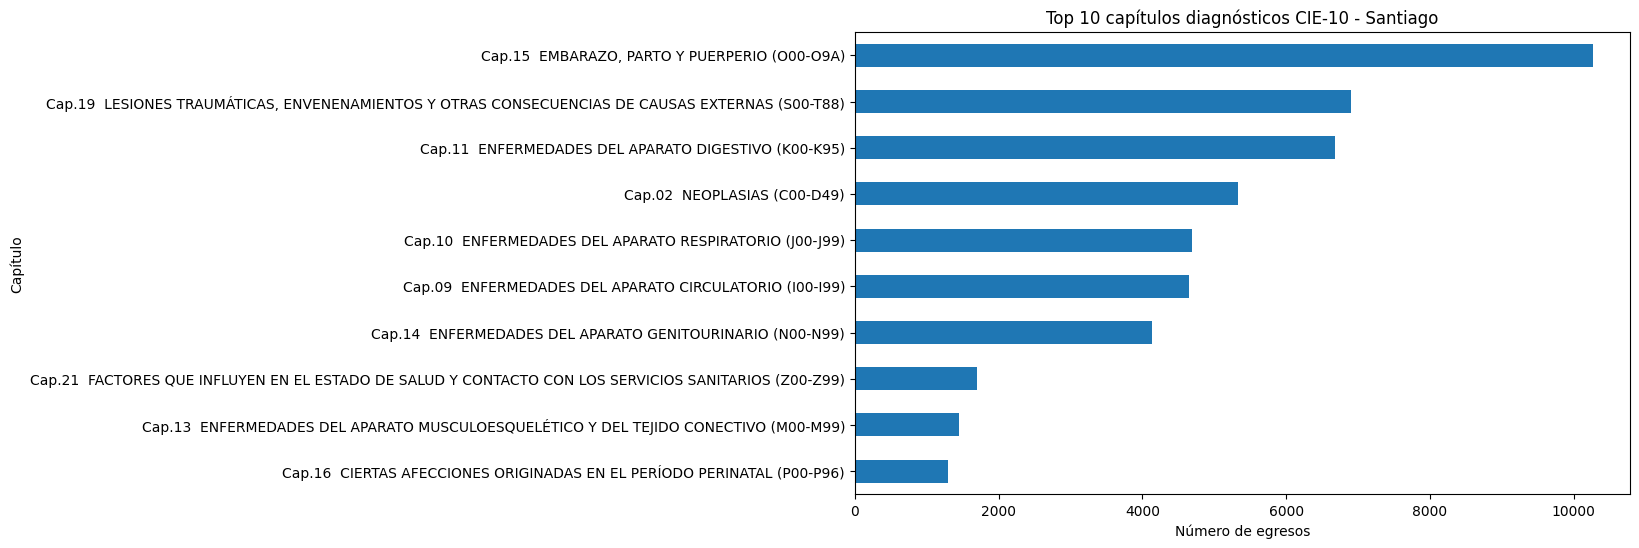

,count,count
0,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",10265
1,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",6907
2,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,6683
3,Cap.02 NEOPLASIAS (C00-D49),5324
4,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,4683
5,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,4647
6,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,4129
7,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,1705
8,Cap.13 ENFERMEDADES DEL APARATO MUSCULOESQUEL...,1452
9,Cap.16 CIERTAS AFECCIONES ORIGINADAS EN EL PE...,1290


In [ ]:

# Top 10 capítulos
top10_chapters = grd_com["Capitulo"].value_counts(dropna=True).head(10).sort_values()

plt.figure(figsize=(10,6))
top10_chapters.plot(kind="barh")
plt.title("Top 10 capítulos diagnósticos CIE-10 - Santiago")
plt.xlabel("Número de egresos")
plt.ylabel("Capítulo")
plt.show()

display(top10_chapters.sort_values(ascending=False).reset_index().rename(columns={"index":"Capitulo","Capitulo":"count"}))


### Conclusión

El principal capítulo diagnóstico corresponde a embarazo, parto y puerperio, con más de 10.000 egresos, seguido por lesiones traumáticas y enfermedades digestivas.

Esto indica que la demanda hospitalaria está fuertemente influenciada por causas obstétricas, quirúrgicas y de urgencia.

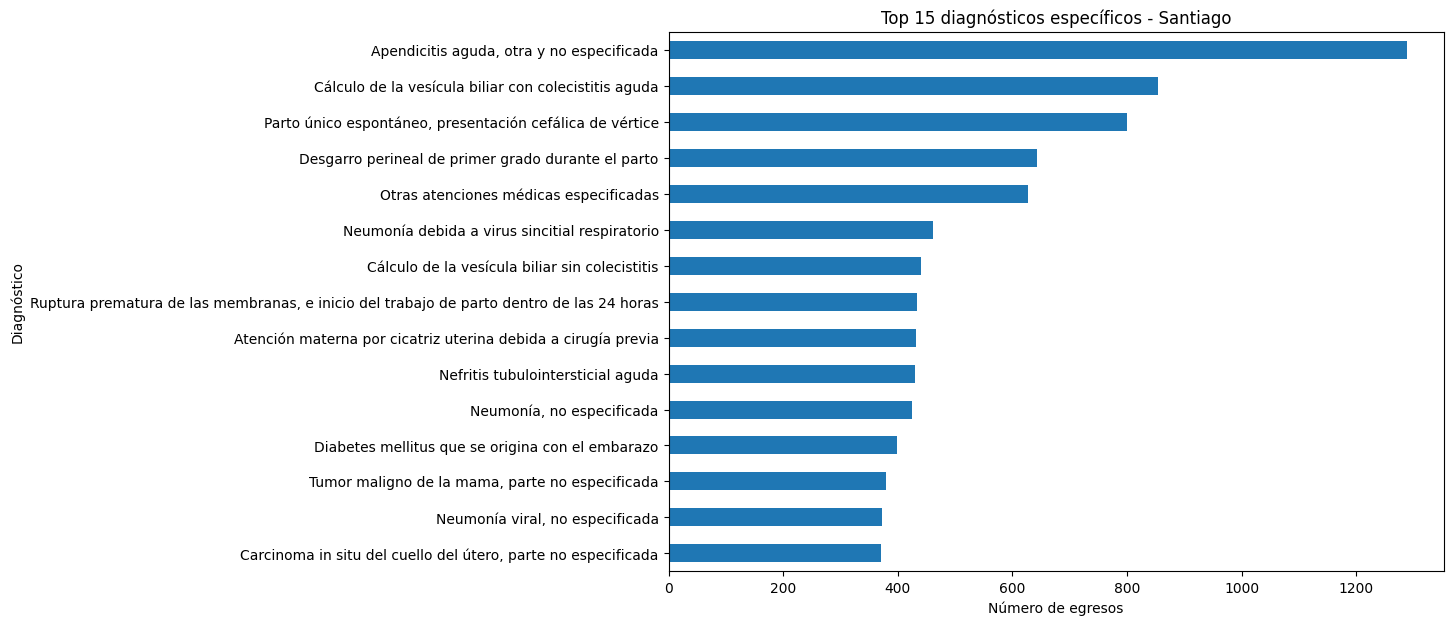

,count,count
0,"Apendicitis aguda, otra y no especificada",1288
1,Cálculo de la vesícula biliar con colecistitis...,855
2,"Parto único espontáneo, presentación cefálica ...",800
3,Desgarro perineal de primer grado durante el p...,643
4,Otras atenciones médicas especificadas,628
5,Neumonía debida a virus sincitial respiratorio,462
6,Cálculo de la vesícula biliar sin colecistitis,441
7,"Ruptura prematura de las membranas, e inicio d...",434
8,Atención materna por cicatriz uterina debida a...,432
9,Nefritis tubulointersticial aguda,430


In [ ]:

# Top 15 diagnósticos
top15_diag = grd_com["Descripcion"].value_counts(dropna=True).head(15).sort_values()

plt.figure(figsize=(10,7))
top15_diag.plot(kind="barh")
plt.title("Top 15 diagnósticos específicos - Santiago")
plt.xlabel("Número de egresos")
plt.ylabel("Diagnóstico")
plt.show()

display(top15_diag.sort_values(ascending=False).reset_index().rename(columns={"index":"Descripcion","Descripcion":"count"}))


### Conclusión

Los diagnósticos más frecuentes incluyen apendicitis aguda, patologías biliares y partos, lo que refuerza la importancia de las atenciones quirúrgicas y obstétricas en el sistema hospitalario de Santiago.

También aparecen enfermedades respiratorias y crónicas, lo que refleja una demanda diversa.

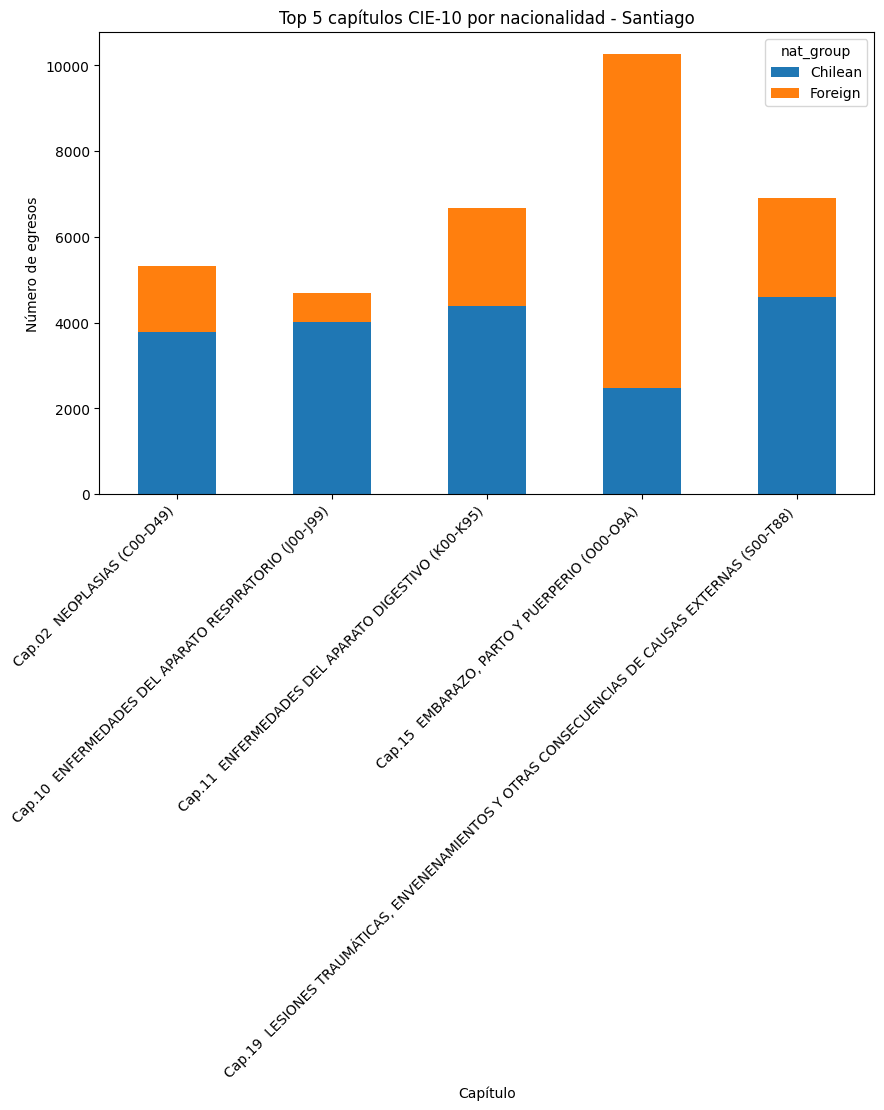

,Capitulo,nat_group,count
0,Cap.02 NEOPLASIAS (C00-D49),Chilean,3774
1,Cap.02 NEOPLASIAS (C00-D49),Foreign,1550
2,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,Chilean,4018
3,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,Foreign,665
4,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Chilean,4388
5,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Foreign,2295
6,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Chilean,2485
7,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Foreign,7780
8,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Chilean,4593
9,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Foreign,2314


In [ ]:

# Top 5 capítulos por nacionalidad
top5_chapters = grd_com["Capitulo"].value_counts(dropna=True).head(5).index.tolist()

chap_nat = (
    grd_com[grd_com["Capitulo"].isin(top5_chapters)]
    .groupby(["Capitulo", "nat_group"])
    .size()
    .reset_index(name="count")
)

chap_pivot = chap_nat.pivot(index="Capitulo", columns="nat_group", values="count").fillna(0)
chap_pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Top 5 capítulos CIE-10 por nacionalidad - Santiago")
plt.xlabel("Capítulo")
plt.ylabel("Número de egresos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(chap_nat.sort_values(["Capitulo", "nat_group"]))


### Conclusión

Se observa que el capítulo de embarazo, parto y puerperio presenta una alta participación de población extranjera, superando ampliamente a la población chilena.

En cambio, en capítulos como neoplasias y enfermedades respiratorias predominan los egresos de población chilena.

Esto evidencia diferencias claras en el perfil de uso hospitalario según nacionalidad.


### B.2 Estadía, severidad y tipo de alta

- comparar `los` por nacionalidad
- graficar la severidad
- mostrar tipo de alta y tasa de mortalidad intrahospitalaria.

,nat_group,mean,median,min,max,count
0,Chilean,7.682129,3.0,0.0,730.0,23692
1,Foreign,4.817208,2.0,0.0,276.0,12692


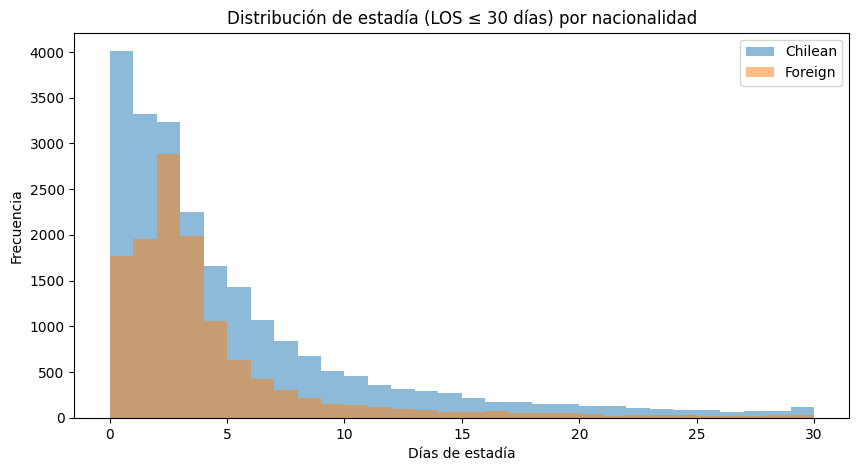

In [ ]:

# LOS por nacionalidad
los_nat = grd_com.groupby("nat_group")["los"].agg(["mean", "median", "min", "max", "count"]).reset_index()
display(los_nat)

grd_los_plot = grd_com[grd_com["los"].notna() & (grd_com["los"] <= 30)].copy()

plt.figure(figsize=(10,5))
for grp, sub in grd_los_plot.groupby("nat_group"):
    plt.hist(sub["los"], bins=30, alpha=0.5, label=grp)
plt.title("Distribución de estadía (LOS ≤ 30 días) por nacionalidad")
plt.xlabel("Días de estadía")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


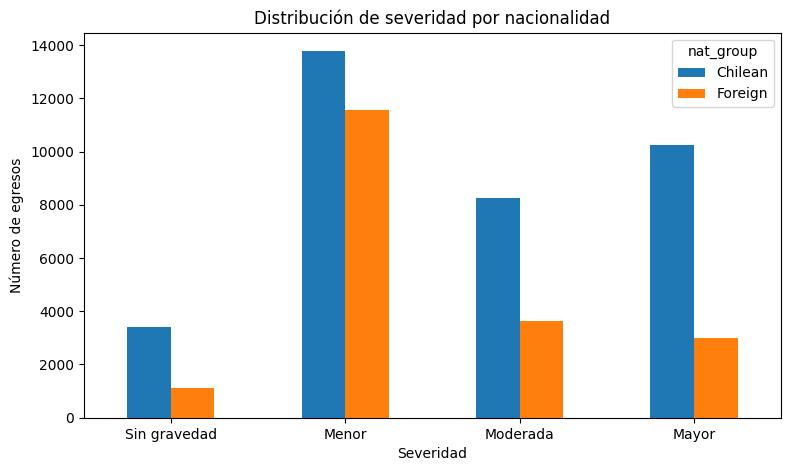

,severity_label,nat_group,count
0,Mayor,Chilean,10240
1,Mayor,Foreign,2990
2,Menor,Chilean,13776
3,Menor,Foreign,11553
4,Moderada,Chilean,8242
5,Moderada,Foreign,3617
6,Sin gravedad,Chilean,3406
7,Sin gravedad,Foreign,1105


In [ ]:

# Etiquetas de severidad
sev_labels = pd.read_excel(FILES["severidad"], sheet_name="Severidad GRD")
sev_labels.columns = ["Severidad", "Severidad_label"]

sev_map = dict(zip(sev_labels["Severidad"], sev_labels["Severidad_label"]))

grd_com["IR_29301_SEVERIDAD"] = pd.to_numeric(grd_com["IR_29301_SEVERIDAD"], errors="coerce")
grd_com["severity_label"] = grd_com["IR_29301_SEVERIDAD"].map(sev_map)

sev_nat = (
    grd_com.groupby(["severity_label", "nat_group"])
    .size()
    .reset_index(name="count")
)

sev_pivot = sev_nat.pivot(index="severity_label", columns="nat_group", values="count").fillna(0)
sev_pivot = sev_pivot.reindex(["Sin gravedad", "Menor", "Moderada", "Mayor"])
sev_pivot.plot(kind="bar", figsize=(9,5))
plt.title("Distribución de severidad por nacionalidad")
plt.xlabel("Severidad")
plt.ylabel("Número de egresos")
plt.xticks(rotation=0)
plt.show()

display(sev_nat)


### Conclusión

La mayoría de los egresos se concentra en niveles de severidad menor y moderada en ambos grupos.

Sin embargo, los casos más graves ("Mayor") son significativamente más frecuentes en población chilena, lo que podría estar asociado a diferencias en edad o comorbilidades.

In [ ]:

# Tipo de alta y mortalidad
tipoalta_dist = grd_com["TIPOALTA"].value_counts(dropna=False).reset_index()
tipoalta_dist.columns = ["TIPOALTA", "count"]
display(tipoalta_dist.head(20))

mortality_nat = (
    grd_com.assign(fallecido = grd_com["TIPOALTA"].astype(str).str.upper().eq("FALLECIDO"))
    .groupby("nat_group")["fallecido"]
    .agg(["mean", "sum", "count"])
    .reset_index()
)

mortality_nat["mortality_rate_pct"] = mortality_nat["mean"] * 100
display(mortality_nat[["nat_group", "sum", "count", "mortality_rate_pct"]])


,TIPOALTA,count
0,DOMICILIO,49945
1,FALLECIDO,1538
2,HOSPITALIZACIÓN DOMICILIARIA,924
3,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,642
4,ALTA VOLUNTARIA,629
5,DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,530
6,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",359
7,DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,140
8,FUGA DEL PACIENTE,130
9,DERIVACIÓN INST. PRIVADA (VOLUNTARIO),92


,nat_group,sum,count,mortality_rate_pct
0,Chilean,1302,35664,3.650740
1,Foreign,236,19265,1.225019


### Conclusión

La mortalidad intrahospitalaria es relativamente baja en ambos grupos, pero es mayor en población chilena (3,65%) que en población extranjera (1,23%).

Esto podría reflejar diferencias en perfil de pacientes, edad o gravedad de los casos atendidos.

### B.3 Vista espacial: tasa de hospitalización por comuna
Se pide un mapa coroplético usando `geopandas`.




In [ ]:
# Tasa por 10.000 habitantes
grd_rates = (
    grd_com.groupby("COMUNA")
    .size()
    .reset_index(name="grd_total")
)

map_comuna_to_code = (
    tarea1_com[["codigo_comuna", "nombre_comuna", "pop_total"]]
    .assign(COMUNA=lambda df: df["nombre_comuna"].str.upper().str.strip())
)

grd_rates = grd_rates.merge(map_comuna_to_code, on="COMUNA", how="left")
grd_rates["grd_rate_per_10k"] = grd_rates["grd_total"] / grd_rates["pop_total"] * 10000

display(grd_rates)


,COMUNA,grd_total,codigo_comuna,nombre_comuna,pop_total,grd_rate_per_10k
0,SANTIAGO,54929,13101,Santiago,438856,1251.640629


### Conclusión

La tasa de egresos hospitalarios en Santiago alcanza aproximadamente 1.251,64 por cada 10.000 habitantes.

Este valor es consistente con una comuna de alta complejidad y elevada actividad hospitalaria, especialmente considerando que el cálculo incluye tres años de datos (2022–2024).

Columnas shapefile: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'region', 'comuna', 'provincia', 'geometry']


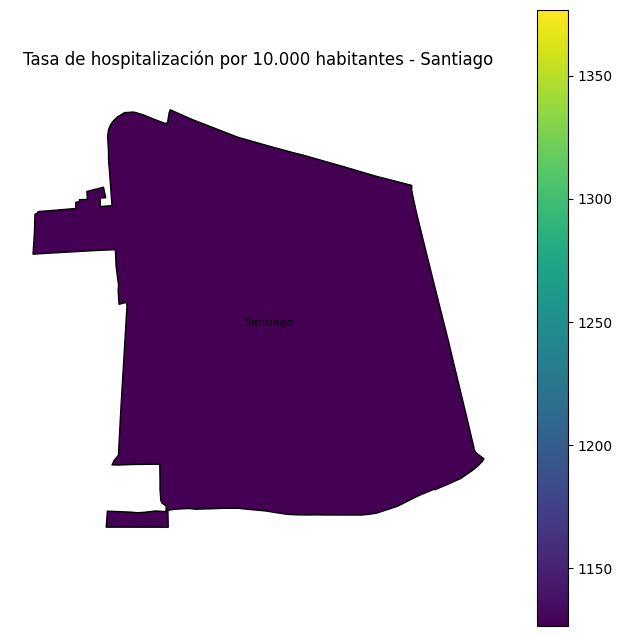

In [ ]:
if gpd is not None:
    # Unificar nombres base del shapefile
    rename_pairs = [
        ("comunas (1).shp", "comunas.shp"),
        ("comunas.dbf", "comunas.dbf"),
        ("comunas.shx", "comunas.shx"),
        ("comunas.prj", "comunas.prj"),
        ("comunas.CPG", "comunas.cpg"),
        ("comunas.sbn", "comunas.sbn"),
        ("comunas (1).sbx", "comunas.sbx"),
    ]

    for src_name, dst_name in rename_pairs:
        src = os.path.join(BASE, src_name)
        dst = os.path.join(BASE, dst_name)
        if os.path.exists(src) and src != dst and not os.path.exists(dst):
            shutil.copy(src, dst)

    shp_path = os.path.join(BASE, "comunas.shp")
    required_sidecars = [
        os.path.join(BASE, "comunas.dbf"),
        os.path.join(BASE, "comunas.shx"),
        os.path.join(BASE, "comunas.prj"),
    ]

    if os.path.exists(shp_path) and all(os.path.exists(p) for p in required_sidecars):
        comunas_gdf = gpd.read_file(shp_path)
        comunas_gdf.columns = [c.lower() for c in comunas_gdf.columns]
        print("Columnas shapefile:", comunas_gdf.columns.tolist())

        possible_code_cols = ["cod_comuna", "codigo_comuna", "cut_com", "comuna"]
        possible_name_cols = ["nom_comuna", "nombre_comuna", "nom_com", "comuna_nom"]

        code_col = next((c for c in possible_code_cols if c in comunas_gdf.columns), None)
        name_col = next((c for c in possible_name_cols if c in comunas_gdf.columns), None)

        if code_col is not None:
            comunas_gdf[code_col] = pd.to_numeric(comunas_gdf[code_col], errors="coerce")
            map_df = comunas_gdf.merge(grd_rates, left_on=code_col, right_on="codigo_comuna", how="left")
        elif name_col is not None:
            comunas_gdf[name_col] = comunas_gdf[name_col].astype(str).str.upper().str.strip()
            map_df = comunas_gdf.merge(grd_rates, left_on=name_col, right_on="COMUNA", how="left")
        else:
            raise ValueError("No se pudo identificar una columna de código o nombre de comuna en el shapefile.")

        # Filtrar a mis comunas para que el mapa muestre solo Santiago
        if "codigo_comuna" in map_df.columns:
            map_df_plot = map_df[map_df["codigo_comuna"].isin(MY_COMUNAS)].copy()
        elif "COMUNA" in map_df.columns:
            map_df_plot = map_df[map_df["COMUNA"].isin(MY_COMUNA_NAMES)].copy()
        else:
            map_df_plot = map_df.copy()

        ax = map_df_plot.plot(column="grd_rate_per_10k", legend=True, figsize=(8, 8), edgecolor="black")
        ax.set_title("Tasa de hospitalización por 10.000 habitantes - Santiago")
        ax.axis("off")

        # Etiquetas si existe nombre de comuna
        label_col = None
        for candidate in ["nombre_comuna", "nom_comuna", "nom_com", "COMUNA"]:
            if candidate in map_df_plot.columns:
                label_col = candidate
                break

        if label_col is not None:
            for _, row in map_df_plot.iterrows():
                if row.geometry is not None and not row.geometry.is_empty:
                    x, y = row.geometry.centroid.coords[0]
                    ax.text(x, y, str(row[label_col]), fontsize=8, ha="center")

        plt.show()
    else:
        print("Aún faltan archivos auxiliares del shapefile o no comparten nombre base.")
else:
    print("geopandas no está disponible en este entorno.")



### B.4 Tabla resumen comunal GRD
La tabla debe incluir conteos, porcentaje de egresos extranjeros, estadía media, severidad media, mortalidad y top 3 capítulos.


In [ ]:
def build_grd_summary(group):
    comuna_name = group.name
    row_t1 = tarea1_com[tarea1_com["nombre_comuna"].str.upper().str.strip() == comuna_name]

    codigo = row_t1["codigo_comuna"].iloc[0] if len(row_t1) else np.nan
    nombre = row_t1["nombre_comuna"].iloc[0] if len(row_t1) else comuna_name.title()
    pop_total = row_t1["pop_total"].iloc[0] if len(row_t1) else np.nan

    grd_total = len(group)
    grd_chilean = (group["nat_group"] == "Chilean").sum()
    grd_foreign = (group["nat_group"] == "Foreign").sum()
    grd_pct_foreign = grd_foreign / grd_total * 100 if grd_total else np.nan

    grd_mean_los = group["los"].mean()
    grd_mean_los_chilean = group.loc[group["nat_group"] == "Chilean", "los"].mean()
    grd_mean_los_foreign = group.loc[group["nat_group"] == "Foreign", "los"].mean()

    grd_mean_severity = pd.to_numeric(group["IR_29301_SEVERIDAD"], errors="coerce").mean()
    grd_mortality_rate = group["TIPOALTA"].astype(str).str.upper().eq("FALLECIDO").mean() * 100
    grd_top3_chapters = ", ".join(group["Capitulo"].value_counts(dropna=True).head(3).index.tolist())
    grd_rate_per_10k = grd_total / pop_total * 10000 if pd.notna(pop_total) and pop_total != 0 else np.nan

    return pd.Series({
        "codigo_comuna": codigo,
        "nombre_comuna": nombre,
        "pop_total": pop_total,
        "grd_total": grd_total,
        "grd_chilean": grd_chilean,
        "grd_foreign": grd_foreign,
        "grd_pct_foreign": grd_pct_foreign,
        "grd_mean_los": grd_mean_los,
        "grd_mean_los_chilean": grd_mean_los_chilean,
        "grd_mean_los_foreign": grd_mean_los_foreign,
        "grd_mean_severity": grd_mean_severity,
        "grd_mortality_rate": grd_mortality_rate,
        "grd_top3_chapters": grd_top3_chapters,
        "grd_rate_per_10k": grd_rate_per_10k
    })

grd_summary = grd_com.groupby("COMUNA").apply(build_grd_summary).reset_index(drop=True)
grd_summary.to_csv(os.path.join(BASE, "output", "tarea2_grd_summary.csv"), index=False)

display(grd_summary)
print("Archivo guardado en:", os.path.join(BASE, "output", "tarea2_grd_summary.csv"))


,codigo_comuna,nombre_comuna,pop_total,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13101,Santiago,438856,54929,35664,19265,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1251.640629


Archivo guardado en: /content/output/tarea2_grd_summary.csv


## 3. Conclusiones

En esta tarea se integraron dos fuentes de datos de salud para la comuna de Santiago.  
Por una parte, **ENO** permitió observar la evolución temporal de las notificaciones, las enfermedades más frecuentes y su distribución por nacionalidad y edad. Por otra, **GRD** permitió caracterizar hospitalizaciones, diagnósticos, severidad, estadía y mortalidad.

En ENO se identificaron **12.186 notificaciones** para Santiago entre 2007 y 2024. La serie muestra aumentos importantes desde 2017, con máximos en 2018 y 2023. La enfermedad claramente dominante es **VIH**, seguida por **Parotiditis** y **Sífilis**. Además, el análisis por nacionalidad sugiere que VIH y sífilis tienen una participación extranjera relativamente alta dentro de sus casos observados.

En GRD se identificaron **54.929 egresos hospitalarios** entre 2022 y 2024. Los principales capítulos diagnósticos fueron **embarazo, parto y puerperio**, **lesiones traumáticas** y **enfermedades del aparato digestivo**. En diagnósticos específicos destacan **apendicitis aguda**, **patología biliar** y varios diagnósticos obstétricos, lo que muestra una demanda hospitalaria diversa, pero con fuerte presencia de causas quirúrgicas y materno-obstétricas.


## 4. Archivos de salida
- `output/tarea2_eno_summary.csv`
- `output/tarea2_grd_summary.csv`


